Price Prediction

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline

In [3]:
DATA_PATH = Path("/content/transactions_articles_sample.csv")

df = pd.read_csv(DATA_PATH)

print("Original shape:", df.shape)
print(df.head().T)  # transpose to inspect columns quickly

Original shape: (88619, 29)
                                                                              0  \
t_dat                                                                2018-09-22   
customer_id                   769a6468fbda93342c3b927a9cf0f96b3ba0a6d120b690...   
article_id                                                          712074001.0   
price                                                                  0.013542   
sales_channel_id                                                            2.0   
product_code                                                           712074.0   
prod_name                                                   Speed cross earring   
product_type_no                                                            70.0   
product_type_name                                                       Earring   
product_group_name                                                  Accessories   
graphical_appearance_no                                    

In [4]:
df["price_real_sek"] = df["price"] * 10000
df["price_usd"] = df["price_real_sek"] / 10.5   # approx SEK→USD conversion

print(df[["price", "price_real_sek", "price_usd"]].head())

      price  price_real_sek  price_usd
0  0.013542      135.423729  12.897498
1  0.011847      118.474576  11.283293
2  0.025407      254.067797  24.196933
3  0.032186      321.864407  30.653753
4  0.033881      338.813559  32.267958


In [5]:
cols_to_drop = [
    "t_dat", "customer_id", "article_id", "product_code",
    "prod_name", "detail_desc", "price", "price_real_sek"  # we now only use price_usd
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print("After dropping unnecessary columns:", df.shape)

# Drop rows missing our target
df = df.dropna(subset=["price_usd"])

# Optional: downsample for RAM
MAX_ROWS = 500_000
if len(df) > MAX_ROWS:
    df = df.sample(MAX_ROWS, random_state=42).reset_index(drop=True)

After dropping unnecessary columns: (88619, 23)


In [6]:
target_col = "price_usd"
y = df[target_col]
X = df.drop(columns=[target_col])

categorical_cols = [c for c in X.columns if X[c].dtype == "object"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print("Categorical cols:", categorical_cols)
print("Numeric cols:", numeric_cols)

Categorical cols: ['product_type_name', 'product_group_name', 'graphical_appearance_name', 'colour_group_name', 'perceived_colour_value_name', 'perceived_colour_master_name', 'department_name', 'index_code', 'index_name', 'index_group_name', 'section_name', 'garment_group_name']
Numeric cols: ['sales_channel_id', 'product_type_no', 'graphical_appearance_no', 'colour_group_code', 'perceived_colour_value_id', 'perceived_colour_master_id', 'department_no', 'index_group_no', 'section_no', 'garment_group_no']


In [7]:
#preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

regressor = HistGradientBoostingRegressor(
    max_depth=8,
    learning_rate=0.1,
    max_iter=200,
    min_samples_leaf=50,
    random_state=42
)

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regressor", regressor)
])


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# 7. TRAIN MODEL
model.fit(X_train, y_train)

# 8. EVALUATE
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE (USD): {rmse:.2f}")
print(f"R² Score:   {r2:.4f}")

RMSE (USD): 11.18
R² Score:   0.7415


In [10]:
import joblib

joblib.dump(model, "hm_price_regressor.pkl")
print("Saved regressor to hm_price_regressor.pkl")

Saved regressor to hm_price_regressor.pkl


In [11]:
# Assuming df is the same dataframe used for training the regressor
price_by_type = df.groupby("product_type_name")["price_usd"].median().sort_values()
print(price_by_type)

product_type_name
Hair string            3.857950
Hair clip              4.019370
Hair ties              4.826473
Fine cosmetics         6.440678
Flip flop              6.440678
                        ...    
Weekend/Gym bag       51.638418
Outdoor Waistcoat     51.638418
Boots                 56.481033
Jacket                64.552058
Coat                 112.978208
Name: price_usd, Length: 95, dtype: float64


In [12]:
# price_by_type you already have:
price_by_type = df.groupby("product_type_name")["price_usd"].median().sort_values()

print("Global median:", df["price_usd"].median())
print(price_by_type.tail(10))  # just to inspect the most expensive ones

Global median: 24.196933010492284
product_type_name
Other shoe            42.154964
Outdoor overall       48.006457
Blazer                48.410008
Underwear corset      48.410008
Underdress            48.410008
Weekend/Gym bag       51.638418
Outdoor Waistcoat     51.638418
Boots                 56.481033
Jacket                64.552058
Coat                 112.978208
Name: price_usd, dtype: float64


In [13]:
def median_for_keywords(keywords):
    """
    keywords: list of strings like ["t-shirt", "top"]
    Returns median price_usd over all rows whose product_type_name
    contains ANY of those keywords (case-insensitive).
    Falls back to global median if nothing matches.
    """
    mask = False
    for kw in keywords:
        mask = mask | df["product_type_name"].str.contains(kw, case=False, na=False)
    if mask.sum() == 0:
        return float(df["price_usd"].median())
    return float(df.loc[mask, "price_usd"].median())

In [14]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

class_to_median_price = {
    "T-shirt/top": median_for_keywords(["t-shirt", "top", "tee"]),
    "Trouser":     median_for_keywords(["trouser", "pants", "jeans"]),
    "Pullover":    median_for_keywords(["pullover", "sweater", "knit"]),
    "Dress":       median_for_keywords(["dress"]),
    "Coat":        median_for_keywords(["coat", "jacket", "waistcoat"]),
    "Sandal":      median_for_keywords(["sandal"]),
    "Shirt":       median_for_keywords(["shirt", "blouse"]),
    "Sneaker":     median_for_keywords(["sneaker", "trainer", "shoe"]),
    "Bag":         median_for_keywords(["bag", "backpack", "pouch"]),
    "Ankle boot":  median_for_keywords(["boot"])
}

print("Class → median price (USD):")
for k, v in class_to_median_price.items():
    print(f"{k:12s}: ${v:.2f}")

Class → median price (USD):
T-shirt/top : $12.90
Trouser     : $32.27
Pullover    : $24.20
Dress       : $32.27
Coat        : $64.55
Sandal      : $14.51
Shirt       : $19.35
Sneaker     : $32.27
Bag         : $24.20
Ankle boot  : $56.48


In [15]:
def estimate_price_from_image(image_path: str):
    _, pred_class_name, probs = predict_class_from_image(image_path)
    base_price = class_to_median_price.get(pred_class_name, df["price_usd"].median())

    print(f"Predicted clothing class: {pred_class_name}")
    print(f"Estimated price (median for this class): ${base_price:.2f}")
    return base_price

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from PIL import Image
import numpy as np

# 1. CONFIG & DEVICE
batch_size = 128
epochs = 30
learning_rate = 0.01
weight_decay = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

torch.manual_seed(42)
if device.type == "cuda":
    torch.cuda.manual_seed_all(42)

# 2. DATASET & DATALOADERS
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(28, padding=2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

data_root = "~/.pytorch/F_MNIST_data/"

print("Loading FashionMNIST...")
train_dataset = datasets.FashionMNIST(
    root=data_root,
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.FashionMNIST(
    root=data_root,
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# 3. MODEL DEFINITION

def get_fashion_resnet(num_classes: int = 10):
    """
    For FashionMNIST (grayscale): train from scratch with 1-channel input
    """
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(
        in_channels=1,
        out_channels=64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(in_features=512, out_features=num_classes)
    return model

def get_pretrained_fashion_resnet(num_classes: int = 10):
    model = models.resnet18(weights='IMAGENET1K_V1')  # Pre-trained on RGB

    # Only replace the final layer
    model.fc = nn.Linear(in_features=512, out_features=num_classes)

    return model

# Use the grayscale version for FashionMNIST training
model = get_fashion_resnet(num_classes=len(class_names))
model = model.to(device)

# 4. LOSS, OPTIMIZER, SCHEDULER
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay  # Now defined
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs
)

# 5. TRAIN & EVAL FUNCTIONS
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    total = 0
    correct = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    total = 0
    correct = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

# 6. TRAINING LOOP

best_acc = 0.0
best_model_path = "fashion_resnet_best.pth"

print(f"Starting classification training for {epochs} epochs...")

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"| LR: {current_lr:.5f} "
        f"| Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% "
        f"| Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% "
        f"(Best Val Acc: {best_acc:.2f}%)"
    )

print("\nTraining complete.")
print(f"Best validation accuracy: {best_acc:.2f}%")
print(f"Best model saved to: {best_model_path}")

Training on: cuda
Loading FashionMNIST...


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 32.6MB/s]


Starting classification training for 30 epochs...
Epoch [1/30] | LR: 0.00997 | Train Loss: 1.0858, Train Acc: 74.42% | Val Loss: 1.4855, Val Acc: 54.49% (Best Val Acc: 54.49%)
Epoch [2/30] | LR: 0.00989 | Train Loss: 0.7987, Train Acc: 86.71% | Val Loss: 0.7832, Val Acc: 87.63% (Best Val Acc: 87.63%)
Epoch [3/30] | LR: 0.00976 | Train Loss: 0.7448, Train Acc: 89.19% | Val Loss: 1.1608, Val Acc: 67.74% (Best Val Acc: 87.63%)
Epoch [4/30] | LR: 0.00957 | Train Loss: 0.7170, Train Acc: 90.33% | Val Loss: 0.7390, Val Acc: 89.84% (Best Val Acc: 89.84%)
Epoch [5/30] | LR: 0.00933 | Train Loss: 0.6998, Train Acc: 91.10% | Val Loss: 0.7041, Val Acc: 90.78% (Best Val Acc: 90.78%)
Epoch [6/30] | LR: 0.00905 | Train Loss: 0.6885, Train Acc: 91.61% | Val Loss: 0.6916, Val Acc: 91.29% (Best Val Acc: 91.29%)
Epoch [7/30] | LR: 0.00872 | Train Loss: 0.6742, Train Acc: 92.22% | Val Loss: 0.7035, Val Acc: 90.69% (Best Val Acc: 91.29%)
Epoch [8/30] | LR: 0.00835 | Train Loss: 0.6651, Train Acc: 92.58% |

In [17]:
!pip install git+https://github.com/openai/CLIP.git

import torch
import clip
from PIL import Image

# 1. LOAD CLIP MODEL

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

print(f"Using device: {device}")
print("CLIP model loaded successfully!")

# 2. DEFINE CATEGORIES

class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

class_to_median_price = {
    "T-shirt": 12.90,
    "Trouser": 32.27,
    "Pullover": 25.81,
    "Dress": 32.27,
    "Coat": 64.55,
    "Sandal": 19.35,
    "Shirt": 19.35,
    "Sneaker": 32.27,
    "Bag": 24.20,
    "Ankle boot": 56.48,
}

# Create text prompts (better descriptions improve accuracy)
text_prompts = [
    "a photo of a t-shirt",
    "a photo of trousers",
    "a photo of a pullover sweater",
    "a photo of a dress",
    "a photo of a coat",
    "a photo of sandals",
    "a photo of a shirt",
    "a photo of sneakers",
    "a photo of a bag",
    "a photo of ankle boots"
]

# Encode text prompts
text_tokens = clip.tokenize(text_prompts).to(device)
with torch.no_grad():
    text_features = model.encode_text(text_tokens)
    text_features /= text_features.norm(dim=-1, keepdim=True)

# 3. PREDICTION FUNCTION

def predict_clothing_clip(image_path: str):
    """
    Predict clothing class using CLIP (zero-shot)
    Works on real images without any training!
    """
    # Load and preprocess image
    image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)

    # Get image features
    with torch.no_grad():
        image_features = model.encode_image(image)
        image_features /= image_features.norm(dim=-1, keepdim=True)

        # Calculate similarity scores
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
        values, indices = similarity[0].topk(5)

    # Get prediction
    pred_idx = indices[0].item()
    pred_class = class_names[pred_idx]
    confidence = values[0].item()

    # Get price
    price = class_to_median_price.get(pred_class, 24.20)

    # Display results
    print(f"\n{'='*60}")
    print(f"Image: {image_path}")
    print(f"{'='*60}")
    print(f"Predicted: {pred_class.upper()}")
    print(f"Confidence: {confidence*100:.2f}%")
    print(f"\nTop-5 predictions:")
    for i in range(5):
        idx = indices[i].item()
        prob = values[i].item()
        print(f"  {class_names[idx]:15s}: {prob*100:.2f}%")
    print(f"\nEstimated price: ${price:.2f} USD")
    print(f"{'='*60}\n")

    return pred_class, price

# 4. USAGE
predict_clothing_clip("/content/coat.png")
predict_clothing_clip("/content/shirt.png")
predict_clothing_clip("/content/ldress.jpg")

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-wfrilaym
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-wfrilaym
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=1e0d71c210aa255e40ec15110510aca7003ad9b09cce1ab55ca509a20f5be0b8
  Stored in directory: /tmp/pip-ephem-wheel-cache-ufdjov8d/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 87.4MiB/s]


Using device: cuda
CLIP model loaded successfully!

Image: /content/coat.png
Model: CLIP (Zero-Shot, No Training)
Predicted: COAT
Confidence: 99.95%

Top-5 predictions:
  Coat           : 99.95%
  Dress          : 0.03%
  Ankle boot     : 0.01%
  Bag            : 0.01%
  Trouser        : 0.01%

Estimated price: $64.55 USD


Image: /content/shirt.png
Model: CLIP (Zero-Shot, No Training)
Predicted: SHIRT
Confidence: 87.84%

Top-5 predictions:
  Shirt          : 87.84%
  T-shirt        : 7.92%
  Pullover       : 2.13%
  Coat           : 1.51%
  Dress          : 0.45%

Estimated price: $19.35 USD


Image: /content/ldress.jpg
Model: CLIP (Zero-Shot, No Training)
Predicted: DRESS
Confidence: 99.27%

Top-5 predictions:
  Dress          : 99.27%
  Shirt          : 0.36%
  Coat           : 0.24%
  T-shirt        : 0.04%
  Bag            : 0.03%

Estimated price: $32.27 USD



('Dress', 32.27)

In [18]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate the same model architecture used for training
fashion_model = get_fashion_resnet(num_classes=len(class_names))
fashion_model.load_state_dict(torch.load("fashion_resnet_best.pth", map_location=device))
fashion_model.to(device)
fashion_model.eval()

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [19]:
all_labels = []
all_preds = []
with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = fashion_model(images)
    _, preds = torch.max(outputs, dim=1)
    all_labels.append(labels.cpu().numpy())
    all_preds.append(preds.cpu().numpy())

all_labels = np.concatenate(all_labels)
all_preds = np.concatenate(all_preds)

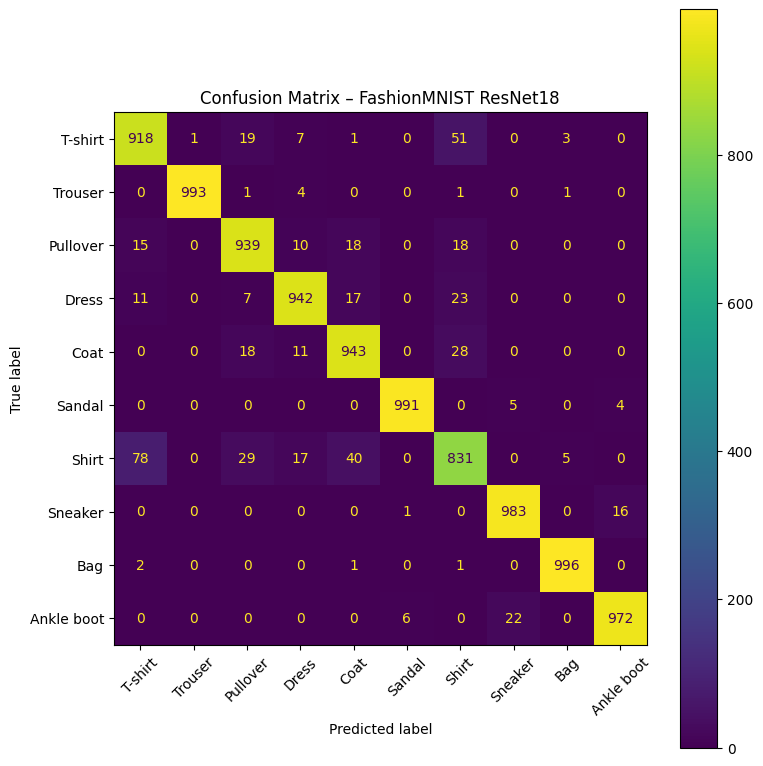

In [20]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix – FashionMNIST ResNet18")
plt.tight_layout()
plt.show()